### **Prediction** harness (target-paired · dual protocol)

Held-out evaluation of the ADR 0005 weighted rate. Design per **ADR 0003 §Update 2026-09-10**:

**Run matrix — 2 targets × 2 city sets × 2 splits**

| target | predictors | metric mapping |
| --- | --- | --- |
| `log(weighted rate)` (absolute) | **pooled/raw** | R² + MAE + Spearman |
| within-city z-score | **per-city demeaned** | rank/concentration (+ within-city R² under 80/20) |

- **City sets:** `wprop` / 10 POC cities, `wtotal` / 5 full-coverage cities.
- **Splits:** stratified **80/20** (interpolation — optimistic) and **LOCO** (extrapolation —
  honest). The **gap** between them is the value of having seen a city before.
- Targets sit on different scorecards — never cross-compare their R²/MAE.
- LightGBM (+ SHAP) probes model form on both target runs. No race/protected predictors.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))

from crime_blockgroup_mapping.constants import CITIES
from regression_modelling.models.cv import (
    load_pooled_table, loco_folds, run_loco, run_holdout,
    loco_metrics, plot_lorenz, make_target,
)
from regression_modelling.models.model import residual_spatial
from regression_modelling.constants import PREDICTOR_COLS

full_cities = [c for c, cfg in CITIES.items() if not cfg.property_only]   # 5 (wtotal)
all_cities  = list(CITIES.keys())                                         # 10 (wprop)
print("full (wtotal):", full_cities)
print("all  (wprop): ", len(all_cities), "cities")

full (wtotal): ['houston', 'chicago', 'atlanta', 'kansas_city', 'detroit']
all  (wprop):  10 cities


In [2]:
pool5  = load_pooled_table(full_cities)   # wtotal / 5
pool10 = load_pooled_table(all_cities)    # wprop  / 10
print("pool5 :", pool5.shape, "| pool10:", pool10.shape)

  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs


  kansas_city         473 BGs
  detroit             622 BGs
  pooled             5314 BGs across 5 cities
  dropped 22 zero/NaN-pop BGs -> 5292 remain (filtered geoid set for fit + Moran's I + bias join)
  dropped 8 BGs below daytime_pop 100 (small-denominator rate artifacts) -> 5284 remain
  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs
  sacramento          366 BGs
  san_francisco       679 BGs
  pittsburgh          317 BGs
  kansas_city         473 BGs


  columbus            637 BGs
  jacksonville        550 BGs
  detroit             622 BGs
  pooled             7863 BGs across 10 cities


  dropped 32 zero/NaN-pop BGs -> 7831 remain (filtered geoid set for fit + Moran's I + bias join)
  dropped 12 BGs below daytime_pop 100 (small-denominator rate artifacts) -> 7819 remain
pool5 : (5284, 98) | pool10: (7819, 98)


### Target-paired run helper

`run_both(pool, category, mode, demean)` runs the paired config under **both** splits and
returns the two `loco_metrics` tables. `within_city_r2` reports per-city within-city variance
explained (Pearson², affine-invariant → leakage-free) for the z-score target.

In [3]:
def run_both(pool, category, mode, demean):
    loco = run_loco(pool, mode=mode, category=category, demean_by_city=demean)
    hold = run_holdout(pool, mode=mode, category=category, demean_by_city=demean, seed=0)
    return {"loco": loco, "8020": hold}

def within_city_r2(scored, category):
    """Per-city within-city R² = (Pearson corr of y_pred vs log1p(rate))². Affine-invariant,
    so no holdout moments are needed — the honest 'within-city variance explained'."""
    rate = f"{category}_rate"
    rows = []
    for c, g in scored.groupby("holdout_city"):
        y = np.log1p(g[rate].astype(float)); p = g["y_pred"].astype(float)
        r = np.corrcoef(y, p)[0, 1] if len(g) > 2 else np.nan
        rows.append({"city": c, "n": len(g), "within_R2": round(float(r * r), 3)})
    df = pd.DataFrame(rows).set_index("city")
    df.loc["MEAN"] = [int(df["n"].sum()), round(df["within_R2"].mean(), 3)]
    return df

### `log(weighted rate)` · 80/20 vs LOCO

Pooled/raw predictors. Watch `r2_oos` / `mae`: the **80/20 → LOCO** drop is the
interpolation-optimism + cross-city-level-transfer penalty.

In [4]:
log_wtotal = run_both(pool5, "wtotal", "lograte", demean=False)
print("\n== wtotal · log · 80/20 (interpolation) ==")
m_wt_8020 = loco_metrics(log_wtotal["8020"]); print(m_wt_8020[["n","r2_oos","mae","spearman","skill"]].to_string())
print("\n== wtotal · log · LOCO (extrapolation) ==")
m_wt_loco = loco_metrics(log_wtotal["loco"]); print(m_wt_loco[["n","r2_oos","mae","spearman","skill"]].to_string())
print(f"\nPOOLED r2_oos gap (80/20 - LOCO): "
      f"{m_wt_8020.loc['POOLED','r2_oos'] - m_wt_loco.loc['POOLED','r2_oos']:+.3f}")

LOCO — target mode = 'lograte' (wtotal)


  holdout=atlanta        n_train= 4645 scored=  369 adjR2_in= 0.480
  holdout=chicago        n_train= 2950 scored= 2064 adjR2_in= 0.449


  holdout=detroit        n_train= 4414 scored=  600 adjR2_in= 0.476


  holdout=houston        n_train= 3478 scored= 1536 adjR2_in= 0.533
  holdout=kansas_city    n_train= 4569 scored=  445 adjR2_in= 0.467
  -> 5014 BGs scored out-of-sample across 5 folds
HOLDOUT — target mode = 'lograte' (wtotal)


  stratified 80/20 split -> train=4227 test=1057 across 5 cities (seed=0)
  n_train= 4022 scored=  992 adjR2_in= 0.469

== wtotal · log · 80/20 (interpolation) ==


               n  r2_oos   mae  spearman  skill
holdout                                        
atlanta       72   0.487  0.61     0.675  0.692
chicago      407   0.571  0.56     0.794  0.745
detroit      120   0.149  0.53     0.447  0.430
houston      305   0.401  0.65     0.612  0.579
kansas_city   88   0.537  0.67     0.746  0.731
POOLED       992   0.508  0.60     0.730  0.651

== wtotal · log · LOCO (extrapolation) ==
                n  r2_oos   mae  spearman  skill
holdout                                         
atlanta       369  -2.015  1.88     0.707  0.536
chicago      2064   0.491  0.57     0.730  0.703
detroit       600   0.047  0.61     0.428  0.511
houston      1536   0.336  0.71     0.606  0.626
kansas_city   445   0.532  0.68     0.779  0.735
POOLED       5014   0.237  0.72     0.626  0.577

POOLED r2_oos gap (80/20 - LOCO): +0.271


In [5]:
log_wprop = run_both(pool10, "wprop", "lograte", demean=False)
print("\n== wprop · log · 80/20 (interpolation) ==")
m_wp_8020 = loco_metrics(log_wprop["8020"]); print(m_wp_8020[["n","r2_oos","mae","spearman","skill"]].to_string())
print("\n== wprop · log · LOCO (extrapolation) ==")
m_wp_loco = loco_metrics(log_wprop["loco"]); print(m_wp_loco[["n","r2_oos","mae","spearman","skill"]].to_string())
print(f"\nPOOLED r2_oos gap (80/20 - LOCO): "
      f"{m_wp_8020.loc['POOLED','r2_oos'] - m_wp_loco.loc['POOLED','r2_oos']:+.3f}")

LOCO — target mode = 'lograte' (wprop)
  holdout=atlanta        n_train= 7068 scored=  369 adjR2_in= 0.390


  holdout=chicago        n_train= 5373 scored= 2064 adjR2_in= 0.385


  holdout=columbus       n_train= 6846 scored=  591 adjR2_in= 0.382


  holdout=detroit        n_train= 6837 scored=  600 adjR2_in= 0.372
  holdout=houston        n_train= 5901 scored= 1536 adjR2_in= 0.420


  holdout=jacksonville   n_train= 6899 scored=  538 adjR2_in= 0.384
  holdout=kansas_city    n_train= 6992 scored=  445 adjR2_in= 0.384


  holdout=pittsburgh     n_train= 7137 scored=  300 adjR2_in= 0.396
  holdout=sacramento     n_train= 7077 scored=  360 adjR2_in= 0.387


  holdout=san_francisco  n_train= 6803 scored=  634 adjR2_in= 0.401
  -> 7437 BGs scored out-of-sample across 10 folds
HOLDOUT — target mode = 'lograte' (wprop)
  stratified 80/20 split -> train=6256 test=1563 across 10 cities (seed=0)
  n_train= 5953 scored= 1484 adjR2_in= 0.386

== wprop · log · 80/20 (interpolation) ==


                  n  r2_oos   mae  spearman  skill
holdout                                           
atlanta          72   0.376  0.56     0.627  0.642
chicago         407   0.441  0.47     0.707  0.709
columbus        124   0.529  0.46     0.747  0.754
detroit         119  -0.249  0.41     0.252  0.312
houston         300   0.283  0.67     0.565  0.546
jacksonville    108   0.259  0.74     0.612  0.606
kansas_city      91   0.337  0.64     0.766  0.687
pittsburgh       60   0.481  0.38     0.795  0.798
sacramento       73   0.332  0.59     0.555  0.763
san_francisco   130   0.174  0.58     0.430  0.663
POOLED         1484   0.396  0.55     0.662  0.626

== wprop · log · LOCO (extrapolation) ==
                  n  r2_oos   mae  spearman  skill
holdout                                           
atlanta         369   0.306  0.62     0.610  0.510
chicago        2064   0.359  0.48     0.651  0.646
columbus        591   0.449  0.53     0.696  0.713
detroit         600   0.007  0.48     0.

**Read:** LOCO absolute R² is far below 80/20 — a held-out city's *level* does not transfer
(some folds go negative, e.g. a city the pooled slope over-/under-shoots). This is the
expected finding that motivates the within-city framing below, not a model defect.

### Within-city z-score (demeaned predictors) · the headline

The within estimator. Judge on **rank/concentration** (Spearman, capture@20%-pop, skill);
`within_R2` is the within-city variance explained under 80/20.

In [6]:
wc_wtotal = run_both(pool5, "wtotal", "lograte_within_city", demean=True)
print("== wtotal · within-city z · LOCO (rank metrics) ==")
print(loco_metrics(wc_wtotal["loco"])[["n","skill","capture@20","spearman"]].to_string())
print("\n== wtotal · within-city z · 80/20 within-city R² ==")
print(within_city_r2(wc_wtotal["8020"]["scored"], "wtotal").to_string())

LOCO — target mode = 'lograte_within_city' (wtotal), demeaned-X
  holdout=atlanta        n_train= 4645 scored=  369 adjR2_in= 0.448


  holdout=chicago        n_train= 2950 scored= 2064 adjR2_in= 0.402


  holdout=detroit        n_train= 4414 scored=  600 adjR2_in= 0.483
  holdout=houston        n_train= 3478 scored= 1536 adjR2_in= 0.487


  holdout=kansas_city    n_train= 4569 scored=  445 adjR2_in= 0.439
  -> 5014 BGs scored out-of-sample across 5 folds
HOLDOUT — target mode = 'lograte_within_city' (wtotal), demeaned-X


  stratified 80/20 split -> train=4227 test=1057 across 5 cities (seed=0)
  n_train= 4022 scored=  992 adjR2_in= 0.444
== wtotal · within-city z · LOCO (rank metrics) ==
                n  skill  capture@20  spearman
holdout                                       
atlanta       369  0.532       0.298     0.701
chicago      2064  0.706       0.400     0.720
detroit       600  0.493       0.273     0.442
houston      1536  0.628       0.386     0.613
kansas_city   445  0.729       0.413     0.778
POOLED       5014  0.634       0.369     0.657

== wtotal · within-city z · 80/20 within-city R² ==
                 n  within_R2
city                         
atlanta       72.0      0.479
chicago      407.0      0.589
detroit      120.0      0.195
houston      305.0      0.405
kansas_city   88.0      0.565
MEAN         992.0      0.447


In [7]:
wc_wprop = run_both(pool10, "wprop", "lograte_within_city", demean=True)
print("== wprop · within-city z · LOCO (rank metrics) ==")
print(loco_metrics(wc_wprop["loco"])[["n","skill","capture@20","spearman"]].to_string())
print("\n== wprop · within-city z · 80/20 within-city R² ==")
print(within_city_r2(wc_wprop["8020"]["scored"], "wprop").to_string())

LOCO — target mode = 'lograte_within_city' (wprop), demeaned-X
  holdout=atlanta        n_train= 7068 scored=  369 adjR2_in= 0.365


  holdout=chicago        n_train= 5373 scored= 2064 adjR2_in= 0.349
  holdout=columbus       n_train= 6846 scored=  591 adjR2_in= 0.355


  holdout=detroit        n_train= 6837 scored=  600 adjR2_in= 0.384
  holdout=houston        n_train= 5901 scored= 1536 adjR2_in= 0.379


  holdout=jacksonville   n_train= 6899 scored=  538 adjR2_in= 0.361
  holdout=kansas_city    n_train= 6992 scored=  445 adjR2_in= 0.355


  holdout=pittsburgh     n_train= 7137 scored=  300 adjR2_in= 0.368
  holdout=sacramento     n_train= 7077 scored=  360 adjR2_in= 0.365
  holdout=san_francisco  n_train= 6803 scored=  634 adjR2_in= 0.379
  -> 7437 BGs scored out-of-sample across 10 folds
HOLDOUT — target mode = 'lograte_within_city' (wprop), demeaned-X


  stratified 80/20 split -> train=6256 test=1563 across 10 cities (seed=0)
  n_train= 5953 scored= 1484 adjR2_in= 0.363
== wprop · within-city z · LOCO (rank metrics) ==
                  n  skill  capture@20  spearman
holdout                                         
atlanta         369  0.446       0.302     0.564
chicago        2064  0.661       0.382     0.610
columbus        591  0.710       0.404     0.687
detroit         600  0.472       0.270     0.393
houston        1536  0.600       0.375     0.577
jacksonville    538  0.640       0.420     0.643
kansas_city     445  0.671       0.398     0.727
pittsburgh      300  0.608       0.364     0.589
sacramento      360  0.682       0.471     0.591
san_francisco   634  0.708       0.467     0.528
POOLED         7437  0.611       0.379     0.571

== wprop · within-city z · 80/20 within-city R² ==
                    n  within_R2
city                            
atlanta          72.0      0.351
chicago         407.0      0.471
columbus 

### Concentration curves (LOCO, within-city ranking)

Sort held-out BGs by predicted risk; Y = cumulative crime captured, X = cumulative
population. Distance above the diagonal = usable ranking skill in an unseen city.

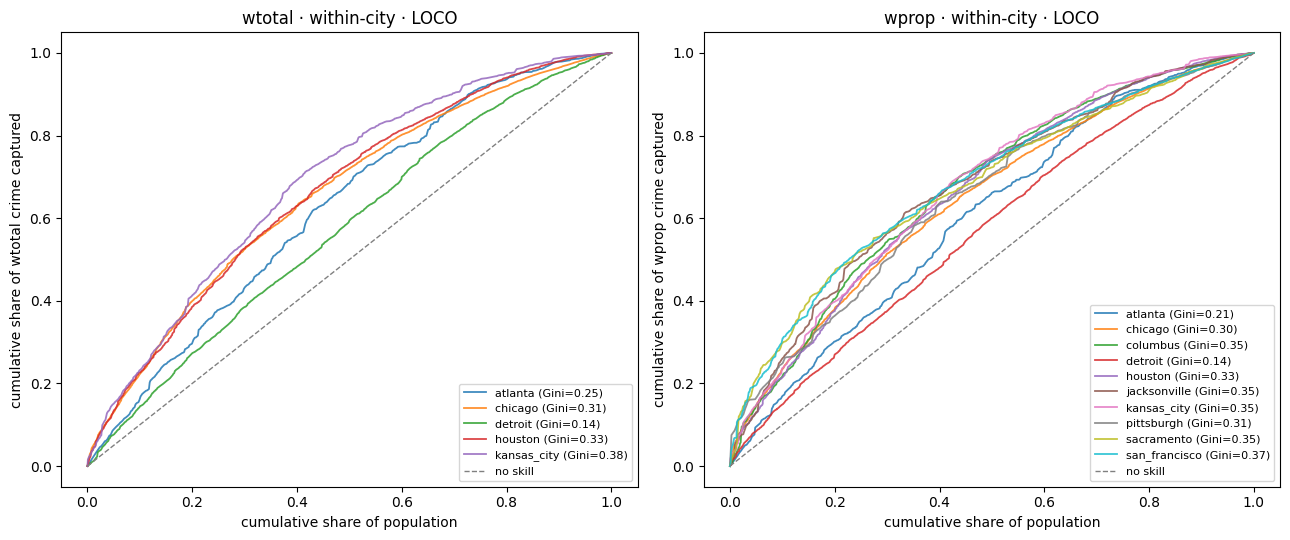

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
plot_lorenz(wc_wtotal["loco"], ax=ax[0]); ax[0].set_title("wtotal · within-city · LOCO")
plot_lorenz(wc_wprop["loco"],  ax=ax[1]); ax[1].set_title("wprop · within-city · LOCO")
plt.tight_layout(); plt.show()

### Residual diagnostics & Moran's I (out-of-sample, absolute log target)

OOS residual = `log1p(rate) − y_pred` on the LOCO absolute model. Positive Moran's I ⇒
residuals cluster spatially ⇒ a spatial control is the next lever (deferred, ADR 0003).

Atlanta state block groups loaded: 7,441


Atlanta city boundary loaded: 1 row(s)


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 426 / 7,441


Chicago state block groups loaded: 9,896


...

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 1,629 / 18,626


Kansas City state block groups loaded: 5,031


Kansas City city boundary loaded: 1 row(s)
Block groups within city: 473 / 5,031


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


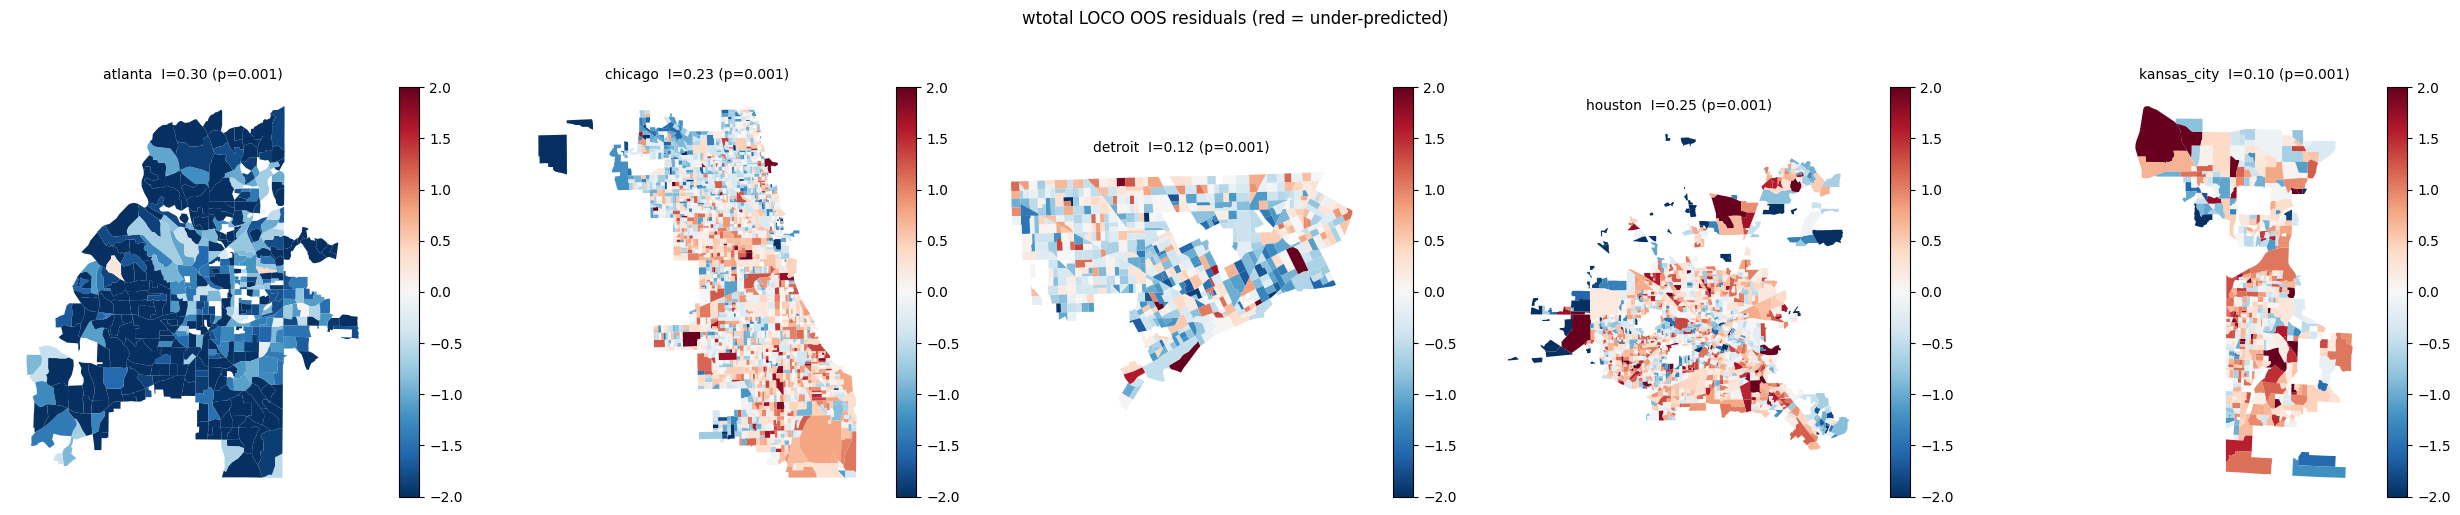

             moran_I  p_sim
city                       
atlanta        0.301  0.001
chicago        0.226  0.001
detroit        0.118  0.001
houston        0.247  0.001
kansas_city    0.098  0.001


In [9]:
def oos_residuals(run, category):
    s = run["scored"].copy()
    s["_resid"] = np.log1p(s[f"{category}_rate"].astype(float)) - s["y_pred"]
    return s

res_wt = oos_residuals(log_wtotal["loco"], "wtotal")
fig, axes = plt.subplots(1, len(full_cities), figsize=(5 * len(full_cities), 5))
rows = []
for ax, c in zip(np.atleast_1d(axes), sorted(full_cities)):
    g = res_wt[res_wt["holdout_city"] == c]
    gdf, mi = residual_spatial(c, g["geoid"].to_numpy(), g["_resid"].to_numpy(), k=6)
    gdf.plot(column="resid", cmap="RdBu_r", vmin=-2, vmax=2, legend=True, ax=ax, edgecolor="none")
    ax.set_title(f"{c}  I={mi.I:.2f} (p={mi.p_sim:.3f})", fontsize=10); ax.axis("off")
    rows.append({"city": c, "moran_I": round(float(mi.I), 3), "p_sim": round(float(mi.p_sim), 4)})
fig.suptitle("wtotal LOCO OOS residuals (red = under-predicted)", y=1.02)
plt.tight_layout(); plt.show()
print(pd.DataFrame(rows).set_index("city").to_string())

### Model-form probe: LightGBM vs OLS (same folds & features)

Gradient boosting on the **absolute log** target under LOCO, both city sets. Trees ignore the
pooled/demeaned distinction (they split on raw values). Compare MAE + rank skill vs the OLS
rows above. `n_jobs=1` (‑1 hangs on this VM).

In [10]:
import lightgbm as lgb

def run_loco_gbm(pool, category, mode="lograte", predictors=PREDICTOR_COLS):
    preds = [p for p in predictors if p in pool.columns]
    parts, models = [], {}
    for city, train, hold in loco_folds(pool):
        tr = train.dropna(subset=preds).copy(); tr["_y"] = make_target(tr, mode, category)
        tr = tr.dropna(subset=["_y"])
        ho = hold.dropna(subset=preds).copy()
        m = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31,
                              subsample=0.8, colsample_bytree=0.8, min_child_samples=40,
                              n_jobs=1, verbose=-1)
        m.fit(tr[preds], tr["_y"].to_numpy())
        ho["y_pred"] = m.predict(ho[preds]); parts.append(ho.assign(holdout_city=city))
        models[city] = m
    return {"scored": pd.concat(parts, ignore_index=True), "fits": {}, "models": models,
            "mode": mode, "category": category, "predictors": preds, "split": "loco"}

gbm_wtotal = run_loco_gbm(pool5,  "wtotal")
gbm_wprop  = run_loco_gbm(pool10, "wprop")
print("== wtotal · log · LOCO: OLS vs LightGBM (POOLED) ==")
print("OLS ", m_wt_loco.loc["POOLED", ["r2_oos","mae","spearman","skill"]].to_dict())
print("GBM ", loco_metrics(gbm_wtotal).loc["POOLED", ["r2_oos","mae","spearman","skill"]].to_dict())
print("\n== wprop · log · LOCO: OLS vs LightGBM (POOLED) ==")
print("OLS ", m_wp_loco.loc["POOLED", ["r2_oos","mae","spearman","skill"]].to_dict())
print("GBM ", loco_metrics(gbm_wprop).loc["POOLED", ["r2_oos","mae","spearman","skill"]].to_dict())

== wtotal · log · LOCO: OLS vs LightGBM (POOLED) ==
OLS  {'r2_oos': 0.237, 'mae': 0.72, 'spearman': 0.626, 'skill': 0.577}
GBM  {'r2_oos': 0.37, 'mae': 0.69, 'spearman': 0.623, 'skill': 0.574}

== wprop · log · LOCO: OLS vs LightGBM (POOLED) ==
OLS  {'r2_oos': 0.342, 'mae': 0.59, 'spearman': 0.613, 'skill': 0.593}
GBM  {'r2_oos': 0.305, 'mae': 0.61, 'spearman': 0.572, 'skill': 0.575}


### SHAP feature importance (LightGBM, largest held-out fold)

Direction + magnitude of each predictor's contribution. Beeswarm on the biggest holdout city
so the OOS behavior is representative.

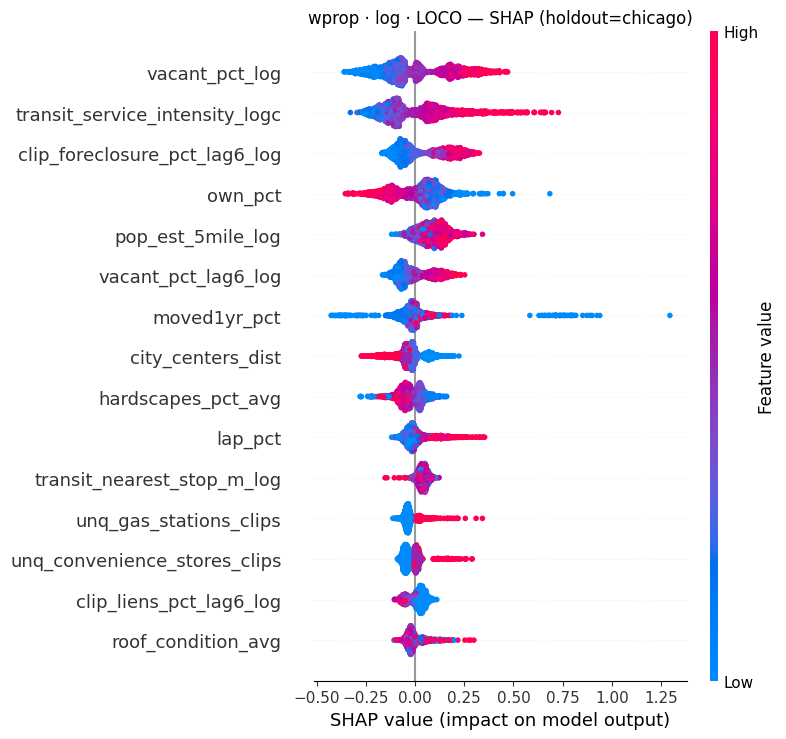

In [11]:
import shap

def shap_beeswarm(gbm_run, title):
    biggest = max(gbm_run["models"], key=lambda c: (gbm_run["scored"]["holdout_city"] == c).sum())
    model = gbm_run["models"][biggest]
    X = gbm_run["scored"].loc[gbm_run["scored"]["holdout_city"] == biggest, gbm_run["predictors"]]
    sv = shap.TreeExplainer(model).shap_values(X)
    shap.summary_plot(sv, X, show=False, max_display=15)
    plt.title(f"{title} — SHAP (holdout={biggest})"); plt.tight_layout(); plt.show()

shap_beeswarm(gbm_wprop, "wprop · log · LOCO")

### Takeaways

- **Absolute log target:** 80/20 R² ≫ LOCO R² — the gap is the interpolation optimism + the
  fact that a new city's *level* doesn't transfer. Report both; the gap is a slide.
- **Within-city z target (demeaned X):** the honest headline — Spearman / capture@20% show we
  can **rank** BGs inside an unseen city even though we can't peg its level. `within_R2`
  (80/20) quantifies within-city variance explained.
- **Residual Moran's I** stays positive OOS ⇒ leftover spatial clustering ⇒ next lever is an
  explicit spatial control (spatial-error / spatial-lag-of-outcome), deferred per ADR 0003.
- **LightGBM** vs OLS: compare MAE (absolute) and skill/Spearman (rank); trees typically win
  on absolute error, tie on rank. SHAP shows which predictors drive risk.
- Next: spatial control, highway predictors, imagery spatial lags, Optuna tuning.